# Stability of Orbitals

This notebook compares the orbital trajectories of particles based on the net force acting on them, using a numerical simulation.

### Introductory Theory
**Newtonian Gravitational Force**

Gravity is the fundamental force responsible for planetary motion.
According to Newton’s Law of Gravitation, every mass attracts every other mass with a force proportional to the product of their masses and inversely proportional to the square of the distance between them.

$$ F_g = \frac{GMm}{r^2} $$

The gravitational force always acts toward the center of the star.
1. As the particle moves closer to the star:
**gravitational force increases**
2. As the particle moves farther away: **gravitational force decreases**
This changing force continuously alters the trajectory of the particle.

**Centrifugal Force**

$$F_c = \frac{mv^2}{r}$$

**Without centrifugal force:**
 the particle would move in a straight line.
Gravity provides this inward force and bends the motion into an orbit.

**Derivation of the Stable Orbit Condition**

A stable circular orbit occurs when the gravitational force exactly equals the centripetal force required for circular motion.
Therefore:
$$F_g = F_c$$
Substituting the force equations:
$$\frac{GMm}{r^2} = \frac{mv^2}{r} \Rightarrow v = \sqrt{\frac{GM}{r}}$$
This equation gives the exact velocity required for a stable circular orbit.
At this velocity, gravity bends the trajectory perfectly and the particle neither falls inward nor escapes outward.

The stable orbit velocity depends on
star mass orbital radius:-
**Larger mass -**
 larger orbital velocity required and
**Larger radius -**
smaller orbital velocity required


**Simulation Parameters**

To numerically simulate orbital motion, we first define the physical and computational parameters.

The particle starts at : **r = [AU, 0]**
and the timestep is set to **dt = 24 * 3600 seconds**
so each step represents one day, and the initial tangential velocity is adjusted to produce different orbital paths.

During the simulation, arrays store the particle’s positions, velocities, and trajectory history. The orbital motion is then advanced using the Leapfrog integrator, which updates position and velocity in staggered steps and is well suited for gravitational dynamics.

**Orbital Behaviour Under Different Velocity Conditions**

The orbital trajectory changes depending on the initial velocity of the particle relative to the stable orbital velocity.

**Case 1:** Stable Circular Orbit
$$ v = \sqrt{\frac{GM}{r}} $$
Behaviour in  this case :
Gravitational attraction and tangential motion remain balanced,
The particle follows a stable, bounded trajectory.

**Case 2:** Inward Spiraling Orbit
$$v < \sqrt{\frac{GM}{r}}$$
Behaviour in this case :
Tangential velocity becomes insufficient,
gravity dominates the motion,
The particle spirals inward toward the star.

**Case 3:** Escape Orbit
$$v > \sqrt{\frac{GM}{r}}$$
Behaviour in this case :
If the particle possesses excess kinetic energy, and gravitational attraction is unable to keep the particle bound, the trajectory escapes outward.

**Velocity Scaling Used in the Simulation**

Different orbital behaviours are generated by changing the initial tangential velocity relative to the stable orbital velocity:
$$v = \sqrt{\frac{GM}{r}}$$


$$
\begin{array}{|c|c|}
\hline
\text{Orbit Type} & \text{Velocity Condition} \\
\hline
\text{Stable Orbit} & v = v_{orbit} \\
\hline
\text{Inward Spiral} & v < v_{orbit} \\
\hline
\text{Escape Orbit} & v > v_{orbit} \\
\hline
\end{array}
$$
This variation in velocity directly changes the orbital trajectory of the particle.

In [1]:
#Necessary Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Circle
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
print("Libraries have been imported")

#Constants
G = 6.67430e-11          # Gravitational constant
M = 1.989e30             # Mass of Sun
R = 6.957e8              # Radius of Sun
AU = 1.496e11            # Astronomical Unit
N_steps = 250
print("Constants have been set")

#Standardizations
plt.rcParams.update({
    'figure.dpi': 130,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,})
# ------------------------------------------------- #
positions = np.zeros((N_steps, 2))
velocities = np.zeros((N_steps, 2))
times = np.zeros(N_steps)
energies = np.zeros(N_steps)
print("Standardizations have been set")

Libraries have been imported
Constants have been set
Standardizations have been set


In [2]:
#Core Physical Functions
def gravitational_force(r, m1, m2):
  r_mag = np.linalg.norm(r)
  return -G * m1 * m2 * r / r_mag**3

def gravitational_potential(r, m1, m2):
    r_mag = np.linalg.norm(r)
    return -G * m1 * m2 / r_mag

def gravitational_acceleration(r):
  r_mag = np.linalg.norm(r)
  if r_mag < 1e-10:      # To avoid singularity at origin
        raise ValueError("Planet has reached the star — simulation invalid.")
  return -G*M / r_mag**3 * r

def kinetic_energy(m, v):
    return 0.5 * m * np.dot(v, v)
def total_energy(m, r, v):
    r_mag = np.linalg.norm(r)
    return 0.5 * m * np.dot(v, v) - (G * M) / r_mag
def angular_momentum(m, r, v):
    return m * np.cross(r, v)

print("All functions have been defined")

All functions have been defined


All particles are intialized from the same position however, with different tangential velocities giving rise to different orbits.

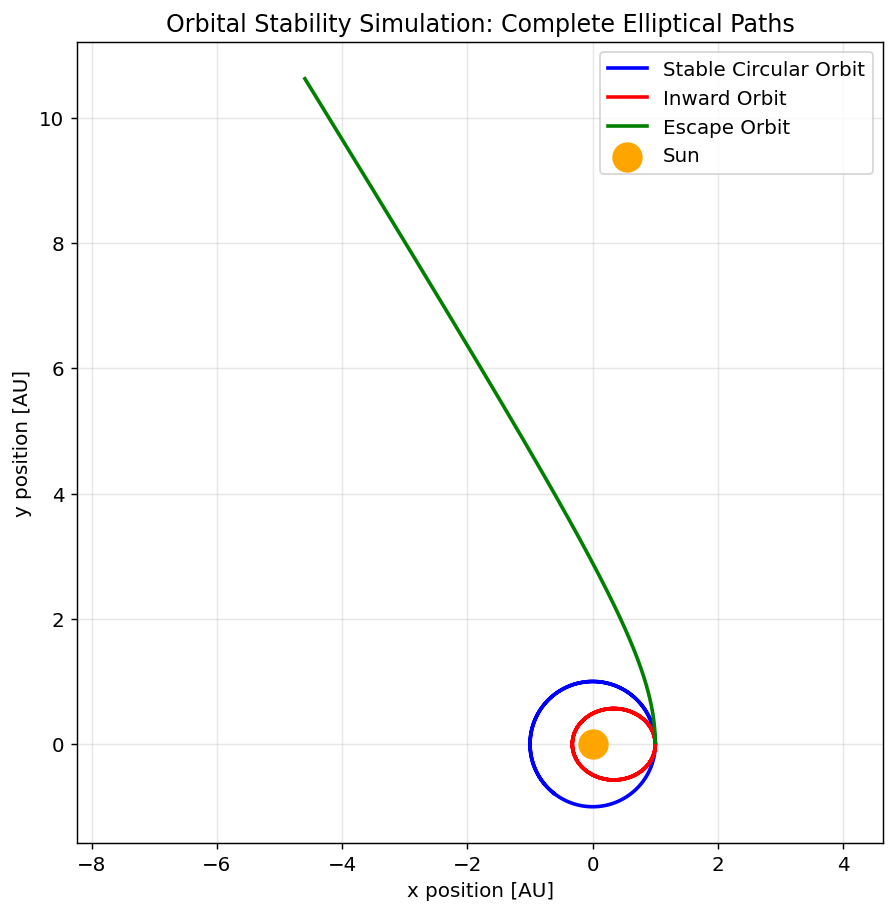

In [3]:
# Orbital stability simulation

def simulate_orbit(v_scale, custom_steps=None):
    steps = custom_steps if custom_steps is not None else N_steps
    # Planet starts 1 AU away from Sun
    r = np.array([AU, 0.0])

    # Stable circular orbit velocity
    v_orbit = np.sqrt(G * M / AU)

    # Initial velocity
    v = np.array([0.0, v_scale * v_orbit])

    # Lists for storing trajectory
    x_points = []
    y_points = []

    # One day timestep
    dt = 24 * 3600

    # Initial gravitational acceleration
    a = gravitational_acceleration(r)

    # Initial half-step velocity (Leapfrog)
    v_half = v + 0.5 * a * dt

    # Leapfrog evolution loop
    for step in range(steps):
        # Position update
        r = r + v_half * dt

        # Gravity changes as planet moves
        try:
            a_new = gravitational_acceleration(r)
        except ValueError:
            break

        # Velocity update
        v_half = v_half + a_new * dt

        # Saving orbit points
        x_points.append(r[0] / AU)
        y_points.append(r[1] / AU)

    return x_points, y_points

# Increased steps to ensure full elliptical paths are completed
N_simulation_steps = 600

# Stable circular orbit (1.0 scale)
x_stable, y_stable = simulate_orbit(1.0, custom_steps=N_simulation_steps)

# Elliptical orbit (0.7 scale) - This will now complete a full ellipse
x_fall, y_fall = simulate_orbit(0.7, custom_steps=N_simulation_steps)

# Escape orbit (1.7 scale)
x_escape, y_escape = simulate_orbit(1.7, custom_steps=N_simulation_steps)

# Plotting all orbital cases together
plt.figure(figsize=(8,8))

# Stable orbit
plt.plot(x_stable, y_stable, linewidth=2, label="Stable Circular Orbit", color='blue')

# Elliptical orbit (formerly inward spiral)
plt.plot(x_fall, y_fall, linewidth=2, label="Inward Orbit", color='red')

# Escape orbit
plt.plot(x_escape, y_escape, linewidth=2, label="Escape Orbit", color='green')

# Sun at center
plt.scatter(0, 0, s=250, color='orange', label='Sun', zorder=5)

# Labels
plt.xlabel("x position [AU]")
plt.ylabel("y position [AU]")
plt.title("Orbital Stability Simulation: Complete Elliptical Paths")
plt.axis("equal")
plt.legend(loc='upper right')
plt.show()